# Time series examples

In [4]:
import jax
import numpy as np 
import pandas as pd
import seaborn as sns
import flax.linen as nn
import matplotlib.cm as cm
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
from datetime import datetime
from functools import partial
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

from bayes_opt import BayesianOptimization
from rebayes_mini.methods.adaptive import RLPRFilter, RLOUPRFilter
from rebayes_mini.methods.robust_filter import ExtendedFilterIMQ
from rebayes_mini.methods.base_filter import ExtendedFilter, ExtendedFilterUV

In [5]:
%config InlineBackend.figure_format = "retina"
plt.rcParams["font.size"] = 15
plt.rcParams["axes.spines.right"]= False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["figure.figsize"] = (7, 3.0)
plt.rc("text", usetex=True)

sns.set_palette("colorblind")

In [8]:
path = "./data/monthly_migrant_encounters.csv"
df = pd.read_csv(path, skiprows=3, skipfooter=3, engine="python")
df["date"] = pd.to_datetime(df["Month/Year"], format="%m/%Y")
df["encounters"] = df["Total encounters"].apply(lambda x: float(x.replace(",", "")))
df = df.set_index("date")[["encounters"]]

presidents = pd.read_csv("./data/us_presidents_wikidata_style.csv")


presidents["start"] = pd.to_datetime(presidents["start"])
presidents.iloc[-1, -1] = datetime.today()
presidents["end"] = pd.to_datetime(presidents["end"])
presidents = presidents.loc[41:]

In [9]:
def draw_spans_known(ax, alpha=0.3):
    # draw spans
    for _, row in presidents.iterrows():
        start = row["start"]
        end = row["end"]
        ax.axvspan(
            start,
            end,
            color=color_map[row["presidentLabel"]],
            alpha=alpha,
            zorder=0  # keep behind line
        )
    
        start = max(start, df.index[0])
        midpoint = start + (end - start) / 2
        ix_label = label_pres[row["presidentLabel"]]
        n, l = row["presidentLabel"].split(" ")[0][0], row["presidentLabel"].split(" ")[-1][0]
        label = rf"$\psi_t = {n}{l}$"

### Initial plots

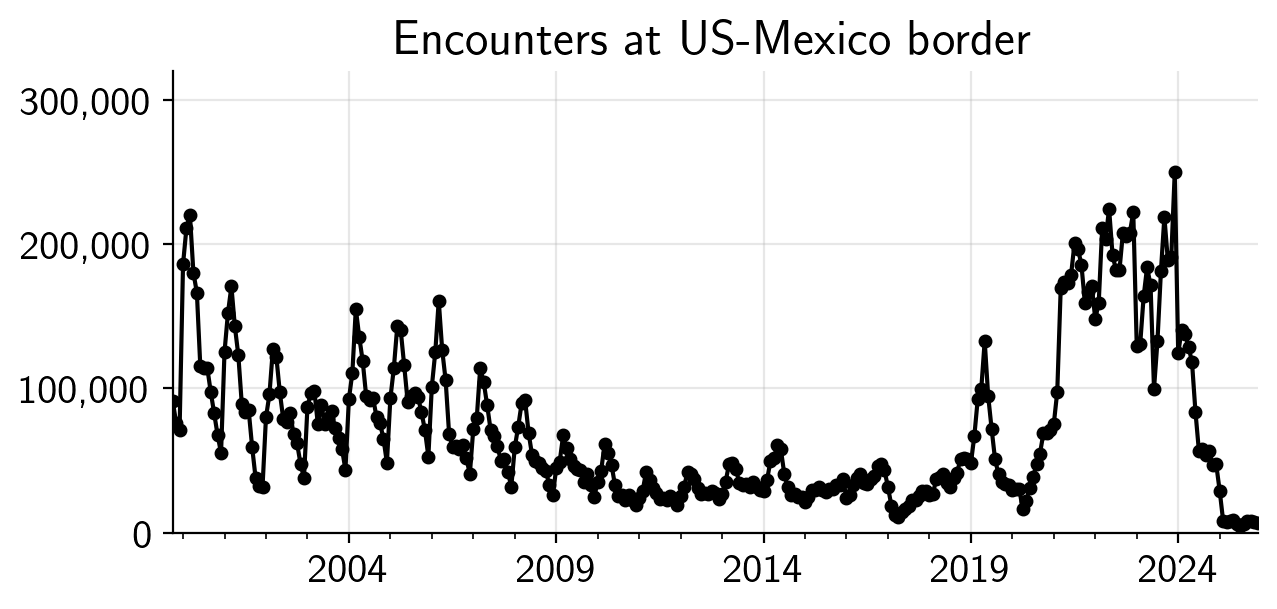

In [10]:
fig, ax = plt.subplots()

# plot data first
df.plot(ax=ax, marker="o", markersize=4, c="black")


ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.legend([], frameon=False)
plt.title("Encounters at US-Mexico border")
plt.xlabel("")
plt.ylim(0, 320_000)
ax.grid(alpha=0.3)


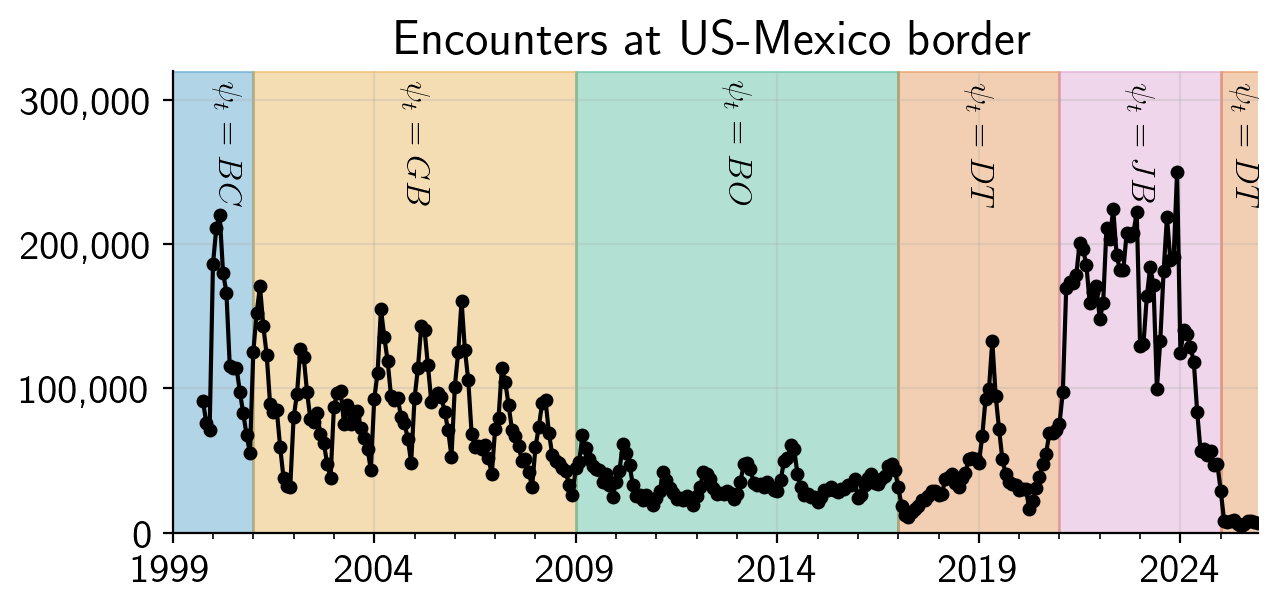

In [11]:

fig, ax = plt.subplots()

# plot data first
df.plot(ax=ax, marker="o", markersize=4, c="black")

# unique presidents → colors
unique_pres = presidents["presidentLabel"].unique()
palette = sns.color_palette()
color_map = {p: palette[i] for i, p in enumerate(unique_pres)}

label_pres = {p: i for i, p in enumerate(unique_pres)}

# draw spans
for _, row in presidents.iterrows():
    start = row["start"]
    end = row["end"]
    ax.axvspan(
        start,
        end,
        color=color_map[row["presidentLabel"]],
        alpha=0.3,
        zorder=0  # keep behind line
    )

    start = max(start, df.index[0])
    midpoint = start + (end - start) / 2
    ix_label = label_pres[row["presidentLabel"]]
    n, l = row["presidentLabel"].split(" ")[0][0], row["presidentLabel"].split(" ")[-1][0]
    label = rf"$\psi_t = {n}{l}$"
    ax.text(midpoint, 270_000, label, ha="center", va="center", fontsize=12, rotation=-90)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)
plt.xlim(left=datetime(1999, 1, 1))
plt.ylim(0, 320_000)

plt.legend([], frameon=False)
plt.title("Encounters at US-Mexico border")
plt.xlabel("")
ax.grid(alpha=0.3)
# plt.savefig("../figures/encounters-regime.png", dpi=300, bbox_inches="tight")

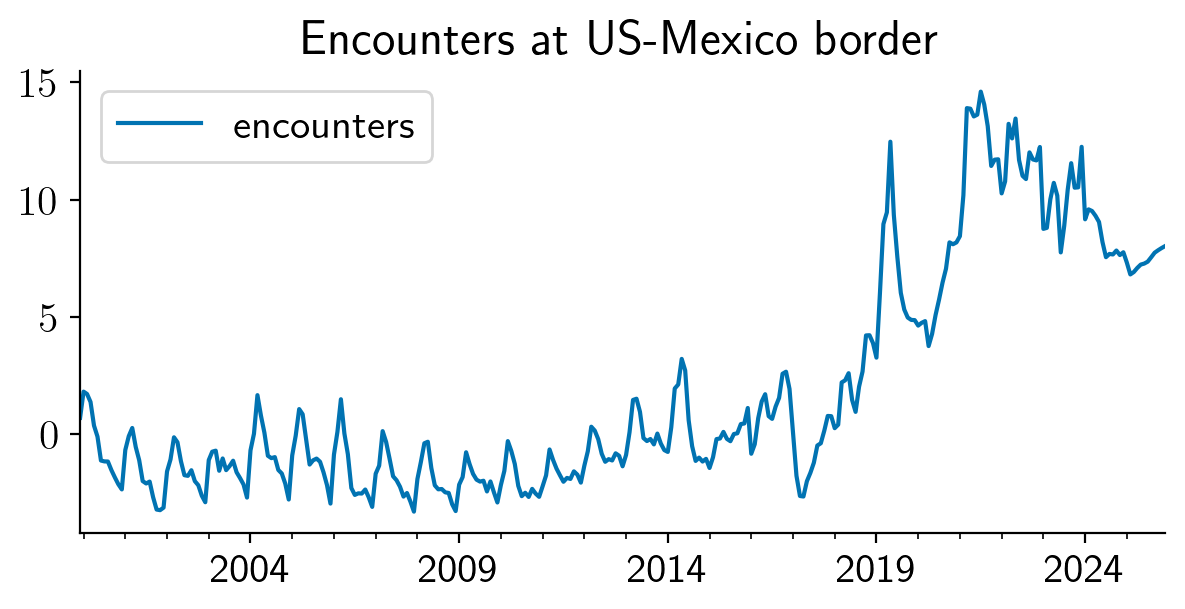

In [12]:
df_norm = df.diff(1)
# df_norm = df_norm / df_norm.std()
df_norm = (df_norm - df_norm.ewm(span=48).mean()) / df_norm.ewm(span=48).std()
# df_norm = df_norm / np.sqrt(np.power(df, 2).ewm(span=100).mean())
df_norm = df_norm.iloc[2:]

df_norm.cumsum().plot()

plt.title("Encounters at US-Mexico border")
plt.xlabel("")
ax.grid(alpha=0.3)


In [13]:
shifts = [0, 1, 3, 6, 12]
D = df_norm.shift(shifts)

In [14]:
col_target = "encounters_0"
y = D[col_target]
X = D.drop(col_target, axis=1)

y = y.values[max(shifts):]

X = X.values[max(shifts):]
X = np.c_[np.ones_like(y), X] # bias term

In [15]:
def model_baseline(theta, x):
    return jnp.array([theta.T @ x])

In [16]:
model = model_baseline

In [17]:
def callback(bel, bel_prior, y, X, filter):
    mean, cov = filter.posterior_predictive_moments(bel_prior, X)

    
    out = {
        "yhat": mean,
        "err": y - mean,
        "cov": cov,
    }
    return out

In [18]:
n_lags = X.shape[1]
dim_params =  n_lags
params_init = jnp.zeros(dim_params)

In [19]:
# base_filter = ExtendedFilter(model, lambda x: 1.0, dynamics_covariance=0.0)
base_filter = ExtendedFilterUV(model, dynamics_covariance=0.0, beta0=1, alpha0=3.0)
bel_init = base_filter.init_bel(params_init, cov=0.5)
partc = partial(callback, filter=base_filter)
_, hist_cst = base_filter.scan(bel_init, y, X, partc)

In [20]:
mae = np.abs(hist_cst["err"]).mean()

# hist_collection[method] = hist["err"]

format(np.mean(np.abs(hist_cst["err"])), ",.6f")

'0.533717'

In [21]:
df_res_cst = pd.DataFrame({
    "forecast": np.asarray(hist_cst["yhat"]).squeeze(),
    "actual": y,
    "error": hist_cst["err"].squeeze(),
    "date": df_norm.index[max(shifts):],
})
df_res_cst = df_res_cst.set_index("date")

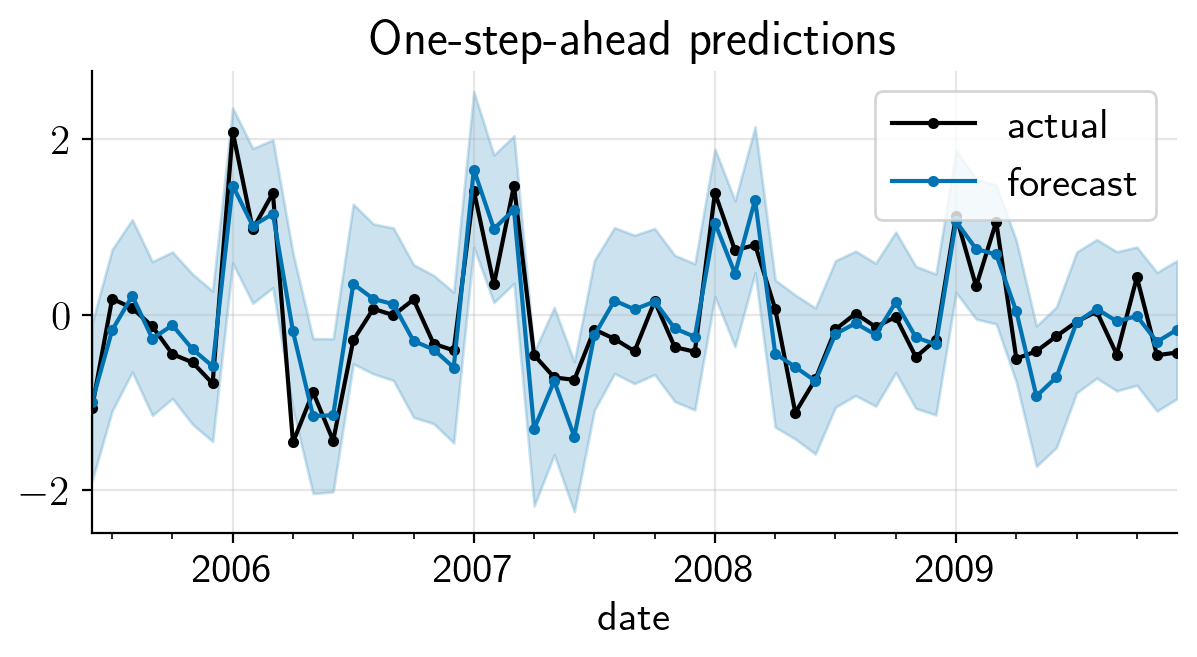

In [22]:
tslice = slice("2005-06", "2009")

window = df_res_cst.loc[tslice]
std = pd.Series(np.sqrt(np.asarray(hist_cst["cov"]).squeeze()), index=df_res_cst.index)

fig, ax = plt.subplots()
window[["actual", "forecast"]].plot(ax=ax, marker="o", markersize=3, color=["black", "C0"])
ax.fill_between(
    window.index,
    (window["forecast"] - 2 * std.loc[window.index]).values,
    (window["forecast"] +  2* std.loc[window.index]).values,
    alpha=0.2,
    color="C0",
    # label="forecast +/- 2 std",
)
ax.legend()
plt.title("One-step-ahead predictions")
ax.grid(alpha=0.3)

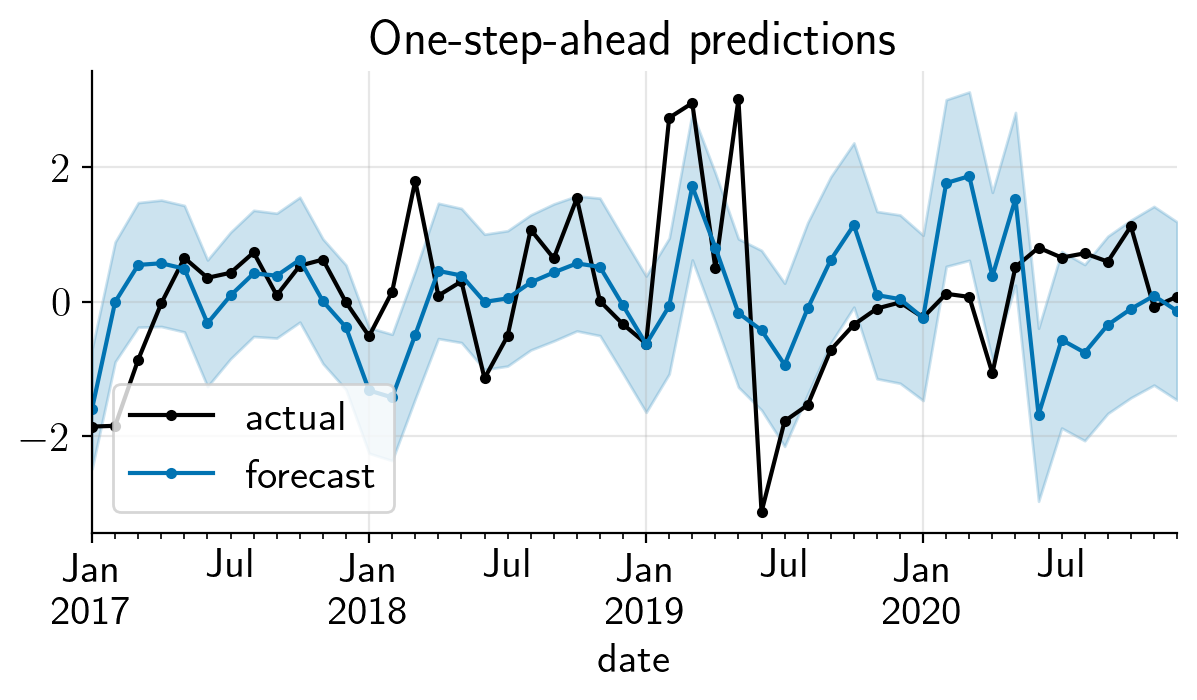

In [23]:
tslice = slice("2017", "2020")

window = df_res_cst.loc[tslice]
std = pd.Series(np.sqrt(np.asarray(hist_cst["cov"]).squeeze()), index=df_res_cst.index)

fig, ax = plt.subplots()
window[["actual", "forecast"]].plot(ax=ax, marker="o", markersize=3, color=["black", "C0"])
ax.fill_between(
    window.index,
    (window["forecast"] - 2 * std.loc[window.index]).values,
    (window["forecast"] +  2* std.loc[window.index]).values,
    alpha=0.2,
    color="C0",
    # label="forecast +/- 2 std",
)
ax.legend(loc="lower left")
plt.title("One-step-ahead predictions")
ax.grid(alpha=0.3)

Text(0.5, 0.98, 'Cst — one-step-ahead predictions')

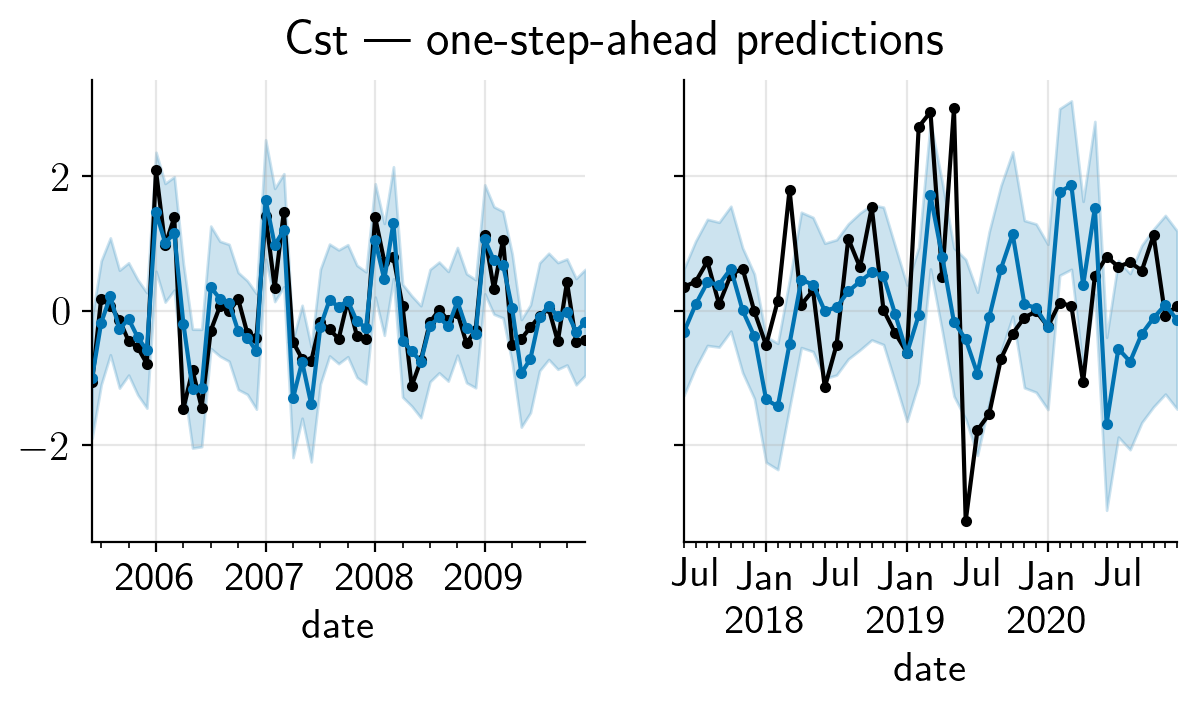

In [24]:
tslices = [slice("2005-06", "2009"), slice("2017-06", "2020")]

fig, axs = plt.subplots(1, 2, sharey=True)

for ax, tslice in zip(axs, tslices):
    window = df_res_cst.loc[tslice]
    std = pd.Series(np.sqrt(np.asarray(hist_cst["cov"]).squeeze()), index=df_res_cst.index)
    
    window[["actual", "forecast"]].plot(ax=ax, marker="o", markersize=3, color=["black", "C0"])
    ax.fill_between(
        window.index,
        (window["forecast"] - 2 * std.loc[window.index]).values,
        (window["forecast"] +  2* std.loc[window.index]).values,
        alpha=0.2,
        color="C0",
        # label="forecast +/- 2 std",
    )
    ax.legend([], frameon=False)
    ax.grid(alpha=0.3)

plt.suptitle("Cst — one-step-ahead predictions")

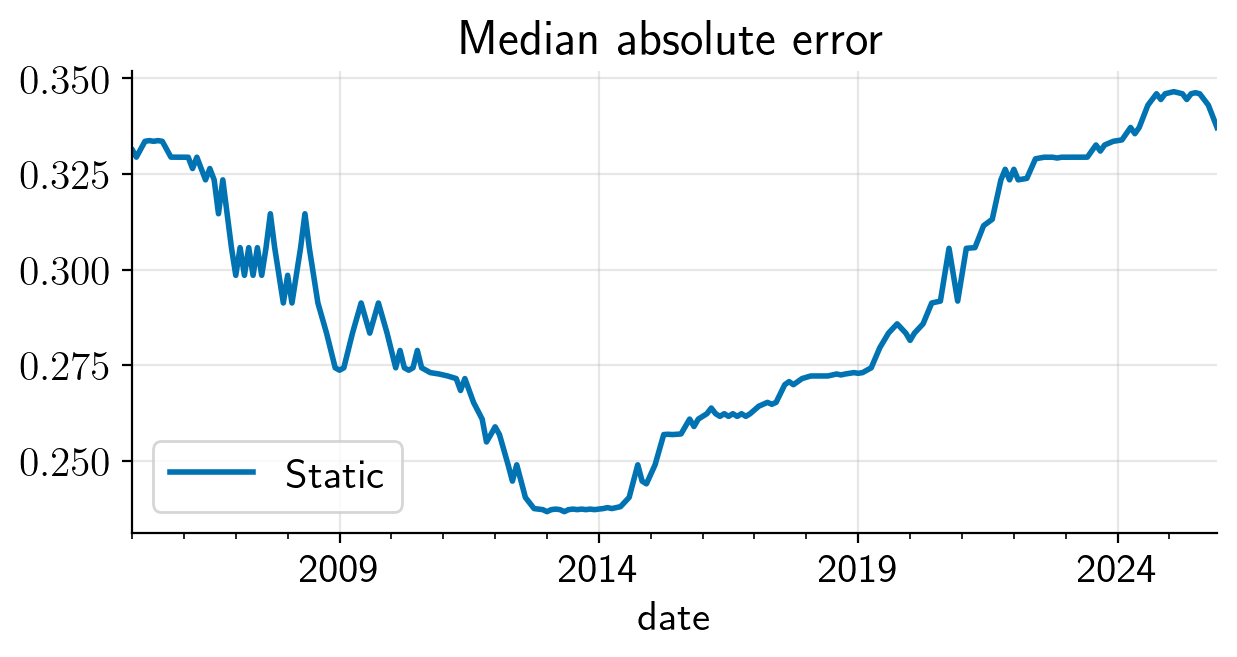

In [25]:
dfs_errors = pd.concat([
    df_res_cst["error"].rename("Static"),
], axis=1)

fig, ax = plt.subplots()

plt.title("Median absolute error")
np.abs(dfs_errors).expanding(48).median().plot(ax=ax, linewidth=2)
ax.set_xlim("2005", "2025-12")
plt.grid(alpha=0.3)
plt.savefig("../figures/encounters-err-cst.png", dpi=300, bbox_inches="tight")

## Known assumed changepoints

In [26]:
df_full = pd.merge_asof(D, presidents, left_index=True, right_on="start").drop(["start", "end"], axis=1)

df_full["presidentLabel"] = df_full["presidentLabel"].apply(lambda x: label_pres[x])
df_full["presidentLabel"] = (df_full["presidentLabel"].diff() != 0) * 1.0
df_full.iloc[0, -1] = 0

In [27]:
col_target = "encounters_0"
col_shift = "presidentLabel"
y = df_full[col_target]
psi = df_full[col_shift]
X = df_full.drop([col_target, col_shift], axis=1)

X = X.values[max(shifts):]
y = y.values[max(shifts):]
psi = psi.values[max(shifts):]

In [28]:
def callback(bel, bel_prior, y, X, filter):
    mean, cov = filter.posterior_predictive_moments(bel_prior, X)

    
    out = {
        "yhat": mean,
        "err": y - mean,
        "cov": cov,
    }
    return out

In [29]:
n_lags = X.shape[1]
dim_params =  n_lags
params_init = jnp.zeros(dim_params)

In [30]:
# base_filter = ExtendedFilterIMQ(model, lambda x: 0.5, dynamics_covariance=0.0)
bel_init = base_filter.init_bel(params_init, cov=0.5)

In [31]:
callback_fn = partial(callback, filter=base_filter)

def scan(bel, y, X, regime_changes):
    def _step(bel, yXpsi):
        y, x, psi = yXpsi

        bel = jax.lax.cond(
            psi==1,
            lambda: bel_init,
            lambda: bel
        )
        
        bel, out = base_filter.step(bel, y, x, callback_fn)
        return bel, out

    bel, hist = jax.lax.scan(_step, bel, (y, X, regime_changes))
    return bel, hist

_, hist_known_cp = scan(bel_init, y, X, psi)

In [32]:
df_res_known_cp = pd.DataFrame({
    "forecast": np.asarray(hist_known_cp["yhat"]).squeeze(),
    "actual": y,
    "error": hist_known_cp["err"].squeeze(),
    "date": df_norm.index[max(shifts):],
})
df_res_known_cp = df_res_known_cp.set_index("date")

In [33]:
mae = np.abs(hist_known_cp["err"]).mean()

# hist_collection[method] = hist["err"]

format(np.mean(np.abs(hist_known_cp["err"])), ",.6f")

'0.545480'

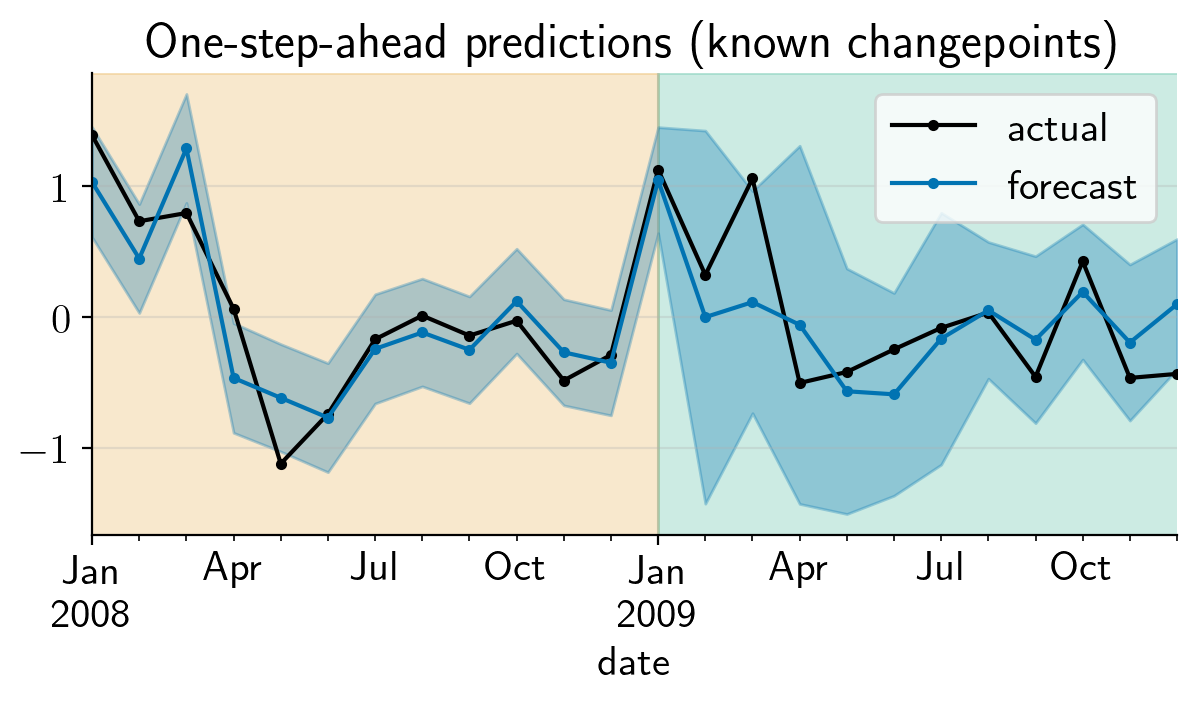

In [34]:
tslice = slice("2008", "2009")

window = df_res_known_cp.loc[tslice]
std = pd.Series(np.sqrt(np.asarray(hist_known_cp["cov"]).squeeze()), index=df_res_known_cp.index)

fig, ax = plt.subplots()
window[["actual", "forecast"]].plot(ax=ax, marker="o", markersize=3, color=["black", "C0"])
ax.fill_between(
    window.index,
    (window["forecast"] - std.loc[window.index]).values,
    (window["forecast"] + std.loc[window.index]).values,
    alpha=0.3,
    color="C0",
    # label="forecast +/- 2 std",
)
ax.legend()
plt.title("One-step-ahead predictions (known changepoints)")
ax.grid(alpha=0.3)

draw_spans_known(ax, alpha=0.2)
plt.savefig("../figures/ohe-forecast-kcp.png", dpi=300, bbox_inches="tight")

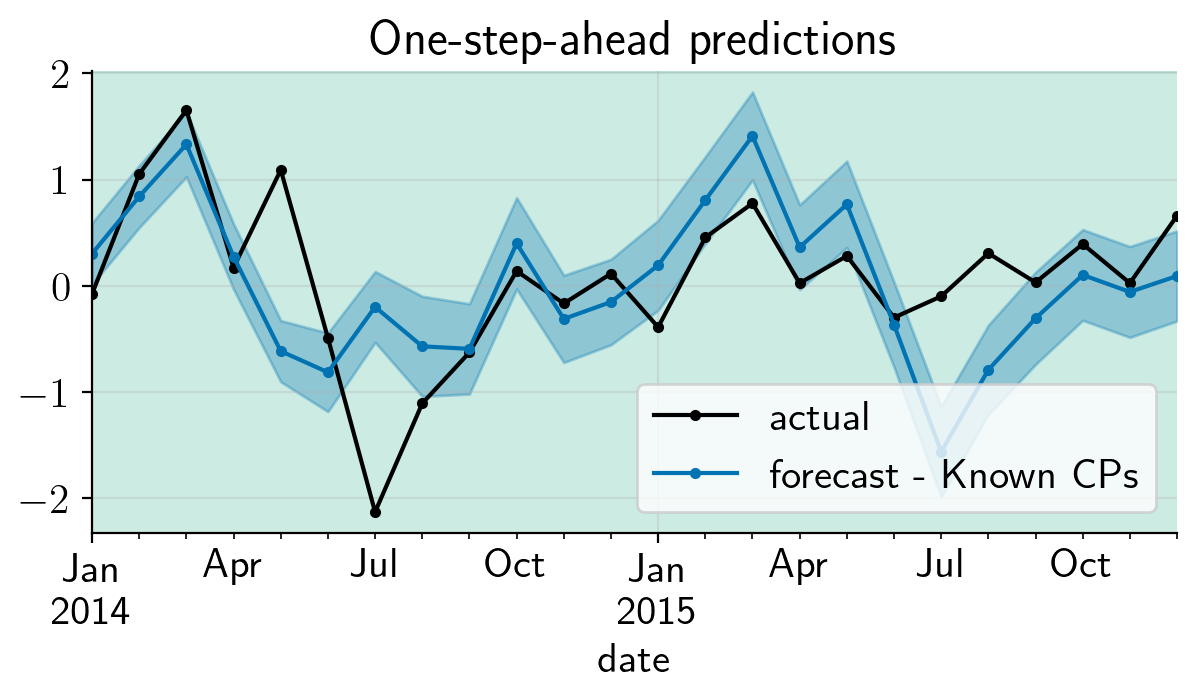

In [35]:
tslice = slice("2014", "2015")

window = df_res_known_cp.loc[tslice]
std = pd.Series(np.sqrt(np.asarray(hist_known_cp["cov"]).squeeze()), index=df_res_known_cp.index)

fig, ax = plt.subplots()
window[["actual", "forecast"]].plot(ax=ax, marker="o", markersize=3, color=["black", "C0"])
ax.fill_between(
    window.index,
    (window["forecast"] - std.loc[window.index]).values,
    (window["forecast"] + std.loc[window.index]).values,
    alpha=0.3,
    color="C0",
    # label="forecast +/- 2 std",
)
ax.legend(["actual", "forecast - Known CPs"])
plt.title("One-step-ahead predictions")
ax.grid(alpha=0.3)

draw_spans_known(ax, alpha=0.2)
plt.savefig("../figures/ohe-forecast-kcp-2.png", dpi=300, bbox_inches="tight")

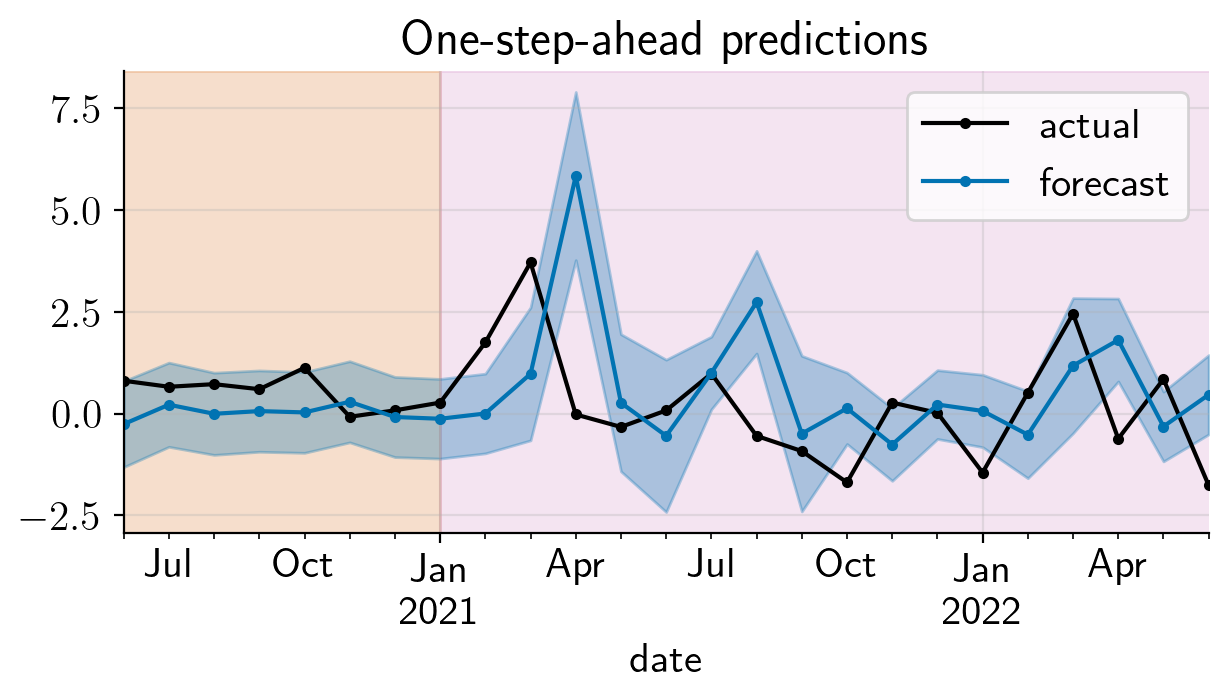

In [36]:
tslice = slice("2020-06", "2022-06")

window = df_res_known_cp.loc[tslice]
std = pd.Series(np.sqrt(np.asarray(hist_known_cp["cov"]).squeeze()), index=df_res_known_cp.index)

fig, ax = plt.subplots()
window[["actual", "forecast"]].plot(ax=ax, marker="o", markersize=3, color=["black", "C0"])
ax.fill_between(
    window.index,
    (window["forecast"] - std.loc[window.index]).values,
    (window["forecast"] + std.loc[window.index]).values,
    alpha=0.3,
    color="C0",
    # label="forecast +/- 2 std",
)
ax.legend()
plt.title("One-step-ahead predictions")
ax.grid(alpha=0.3)

draw_spans_known(ax, alpha=0.2)
# plt.savefig("../figures/ohe-forecast-kcp.png", dpi=300, bbox_inches="tight")

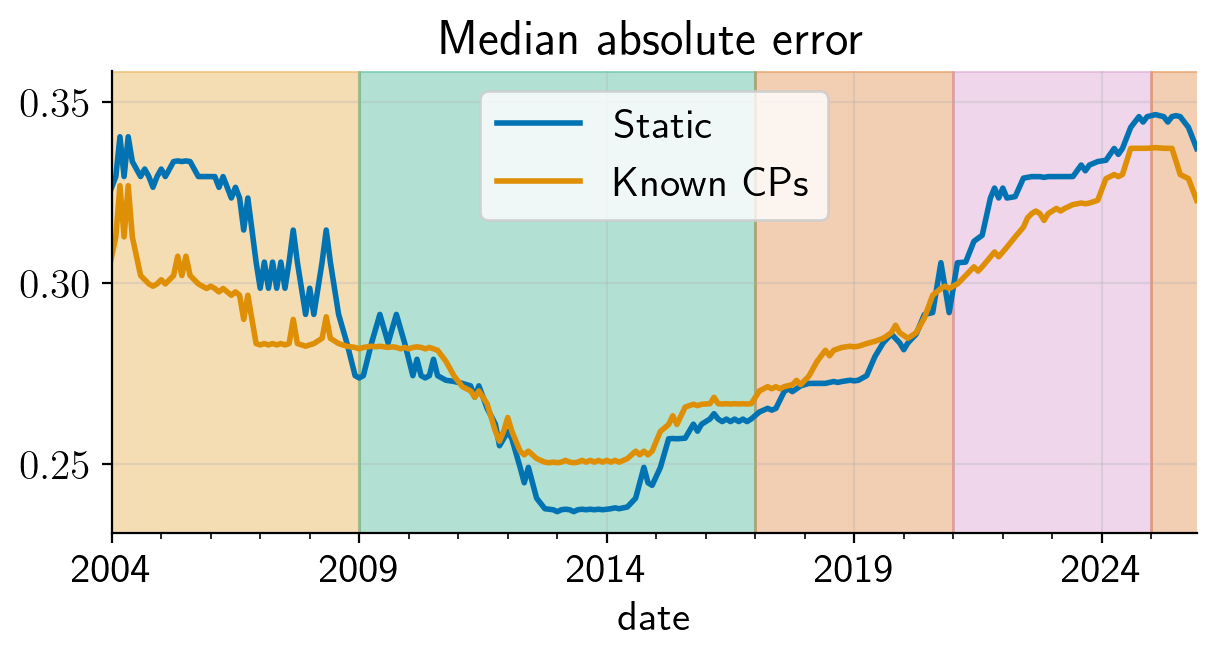

In [37]:
dfs_errors = pd.concat([
    df_res_cst["error"].rename("Static"),
    df_res_known_cp["error"].rename("Known CPs"),
], axis=1)

fig, ax = plt.subplots()

plt.title("Median absolute error")
np.abs(dfs_errors).expanding(12 * 2).median().plot(ax=ax, linewidth=2)
ax.set_xlim("2004", "2025-12")
plt.grid(alpha=0.3)

draw_spans_known(ax)
plt.savefig("../figures/encounters-err-cst+kcp.png", dpi=300, bbox_inches="tight")

## RL-VR

In [38]:
def callback(bel, bel_prev, y, X, filter):
    mean, cov = filter.filter.posterior_predictive_moments(bel_prev, X)


    out = {
        "runlength": bel.runlength,
        "posterior": jnp.exp(bel.log_posterior),
        "yhat": mean,
        "err": mean - y,
        "cov": cov.squeeze()
    }
    return out

In [39]:
# method = "RL-OUPR"
filter = RLOUPRFilter(
    p_change=1/48, deflate_mean=False, filter=base_filter, threshold=0.5, shock=0
)
bel_init = filter.init_bel(params_init, cov=0.2, log_posterior_init=0.0)
partc = partial(callback, filter=filter)

bel_final, hist_rlvr = filter.scan(y[:, None], X, bel_init, partc)
mae = np.abs(hist_rlvr["err"]).mean()
format(np.mean(np.abs(hist_rlvr["err"])), ",.6f")

'0.522053'

In [40]:
df_res_rlvr = pd.DataFrame({
    "forecast": np.asarray(hist_rlvr["yhat"]).squeeze(),
    "actual": y,
    "error": hist_rlvr["err"].squeeze(),
    "runlength": hist_rlvr["runlength"].squeeze() / 12,
    "posterior": hist_rlvr["posterior"].squeeze(),
    "date": df_norm.index[max(shifts):],
})
df_res_rlvr = df_res_rlvr.set_index("date")

In [43]:
posterior = pd.Series(hist_rlvr["posterior"], index=df_res_rlvr["error"].index)

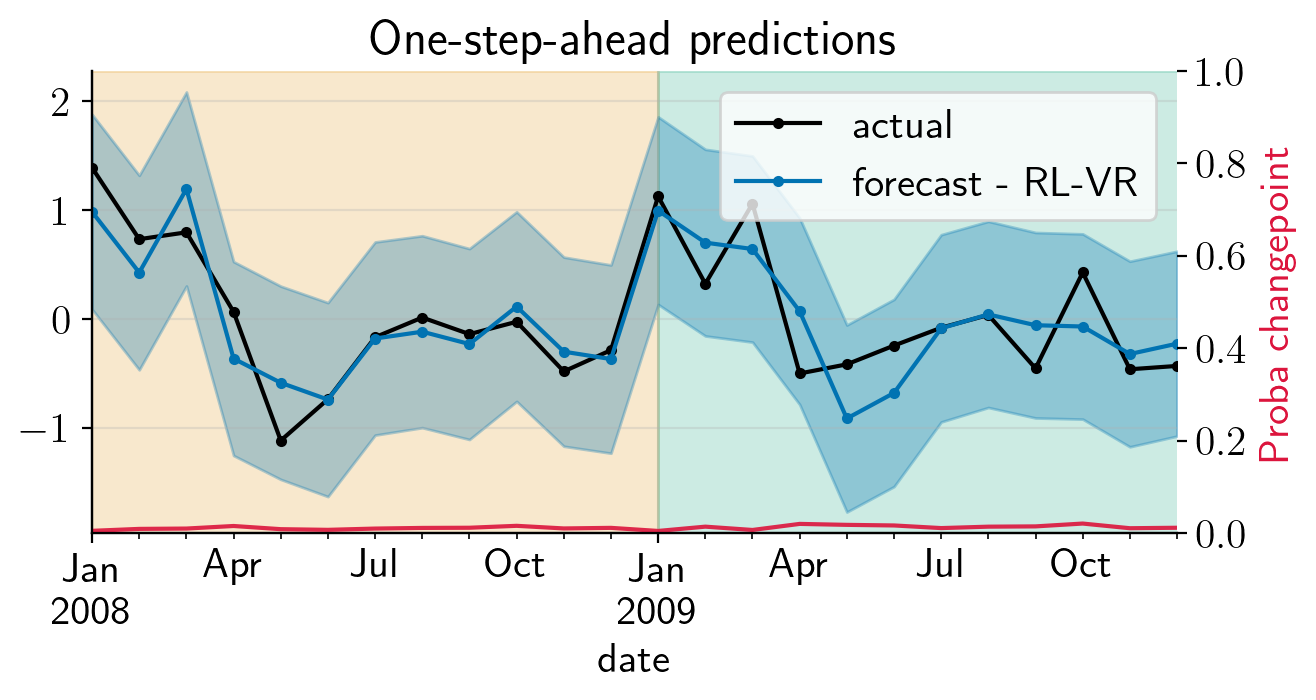

In [44]:
tslice = slice("2008", "2009")

window = df_res_rlvr.loc[tslice]
std = pd.Series(np.sqrt(np.asarray(hist_rlvr["cov"]).squeeze()), index=df_res_known_cp.index)

fig, ax = plt.subplots()
ax2 = ax.twinx()
window[["actual", "forecast"]].plot(ax=ax, marker="o", markersize=3, color=["black", "C0"])
ax.fill_between(
    window.index,
    (window["forecast"] - 2 * std.loc[window.index]).values,
    (window["forecast"] + 2 * std.loc[window.index]).values,
    alpha=0.3,
    color="C0",
    # label="forecast +/- 2 std",
)
ax.legend()
plt.title("One-step-ahead predictions")
ax.grid(alpha=0.3)
ax.legend(["actual", "forecast - RL-VR"])

draw_spans_known(ax, alpha=0.2)

(1-posterior)[tslice].plot(ax=ax2, c="crimson", alpha=0.9)
ax2.set_ylabel("Proba changepoint", color="crimson")
ax2.set_ylim(0, 1)

plt.savefig("../figures/ohe-forecast-rlvr-1.png", dpi=300, bbox_inches="tight")

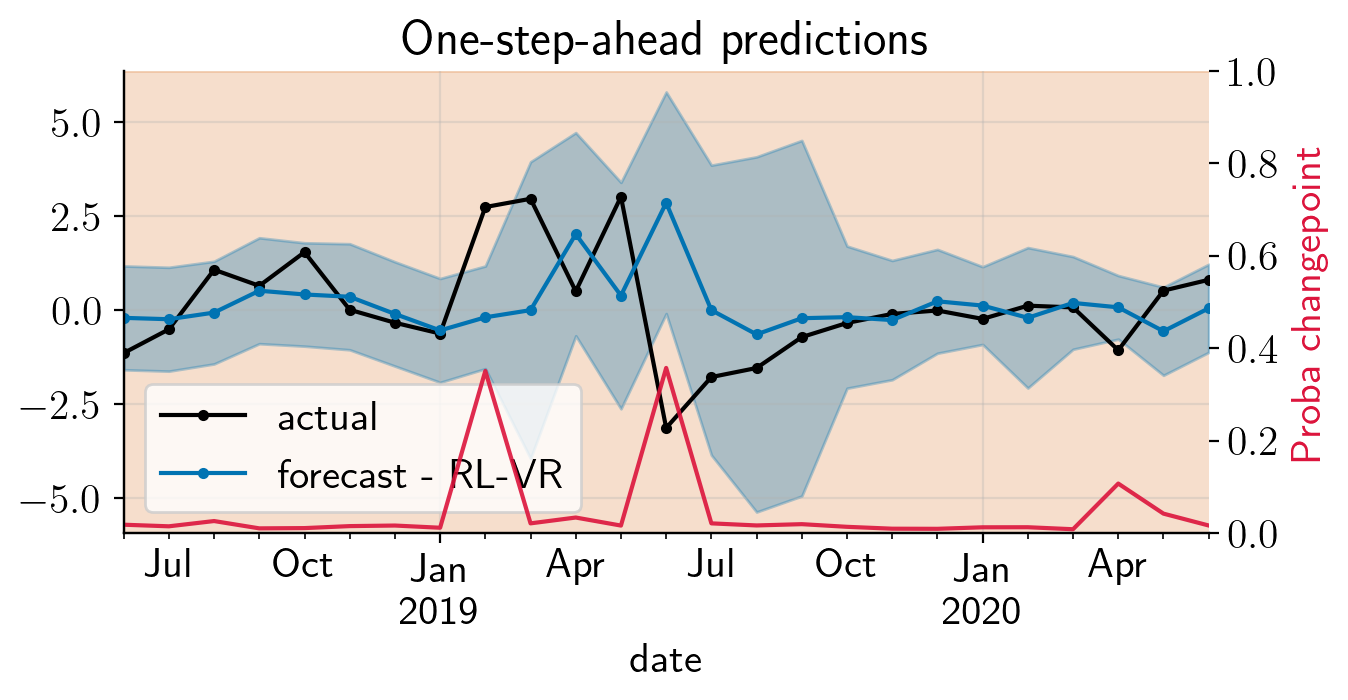

In [45]:
tslice = slice("2018-06", "2020-06")

window = df_res_rlvr.loc[tslice]
std = pd.Series(np.sqrt(np.asarray(hist_rlvr["cov"]).squeeze()), index=df_res_known_cp.index)

fig, ax = plt.subplots()
ax2 = ax.twinx()
window[["actual", "forecast"]].plot(ax=ax, marker="o", markersize=3, color=["black", "C0"])
ax.fill_between(
    window.index,
    (window["forecast"] - 2 * std.loc[window.index]).values,
    (window["forecast"] + 2 * std.loc[window.index]).values,
    alpha=0.3,
    color="C0",
    # label="forecast +/- 2 std",
)
ax.legend()
plt.title("One-step-ahead predictions")
ax.grid(alpha=0.3)
ax.legend(["actual", "forecast - RL-VR"])

draw_spans_known(ax, alpha=0.2)

(1-posterior)[tslice].plot(ax=ax2, c="crimson", alpha=0.9)
ax2.set_ylabel("Proba changepoint", color="crimson")
ax2.set_ylim(0, 1)

plt.savefig("../figures/ohe-forecast-rlvr-2.png", dpi=300, bbox_inches="tight")

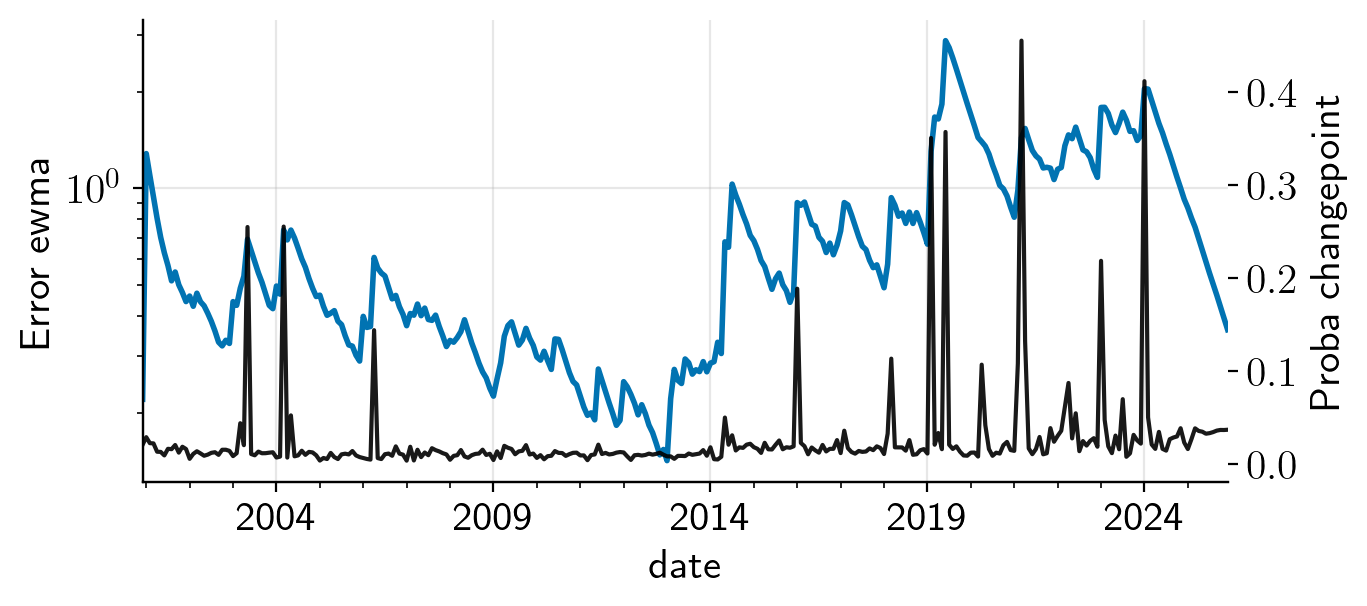

In [46]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
np.sqrt(np.power(df_res_rlvr["error"], 2).ewm(span=12).mean()).plot(ax=ax, label="rlpr", linewidth=2)
(1-posterior).plot(ax=ax2, c="black", alpha=0.9)
ax2.set_ylabel("Proba changepoint")
ax.set_ylabel("Error ewma")
ax.set_yscale("log")
ax.grid(alpha=0.3)

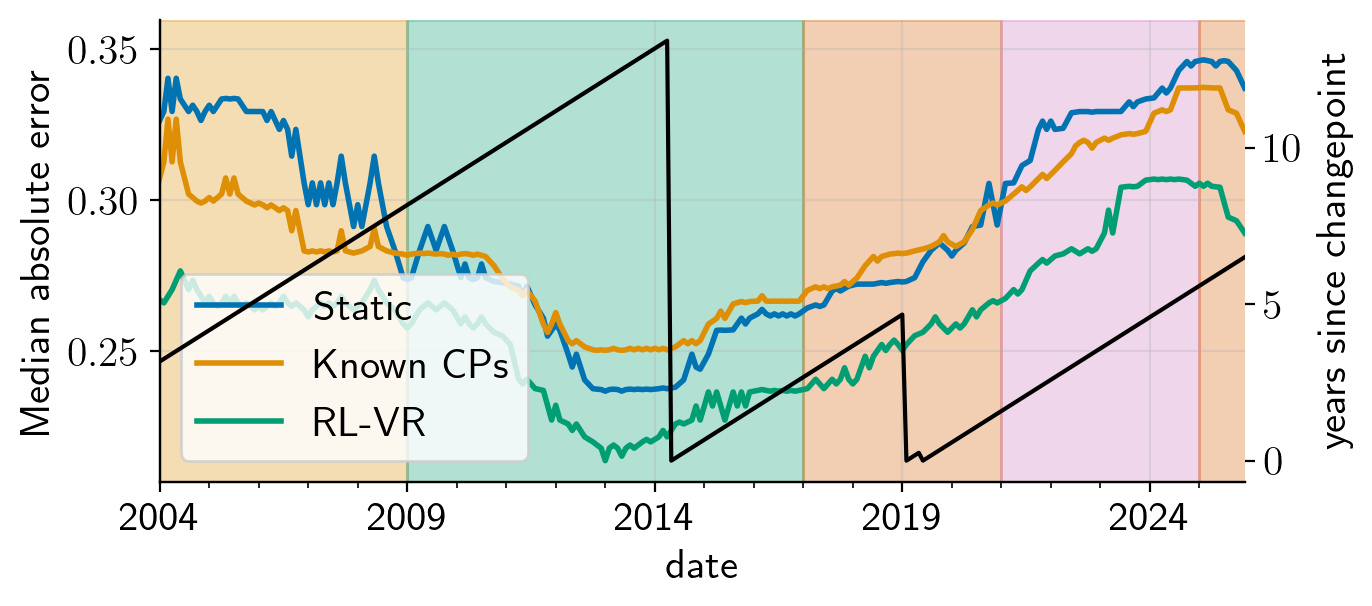

In [47]:
dfs_errors = pd.concat([
    df_res_cst["error"].rename("Static"),
    df_res_known_cp["error"].rename("Known CPs"),
    df_res_rlvr["error"].rename("RL-VR"),
], axis=1)

fig, ax = plt.subplots()
ax2 = ax.twinx()

np.abs(dfs_errors).expanding(12 * 2).median().plot(ax=ax, linewidth=2)

ax.grid(alpha=0.3)
ax.legend(loc="lower left")

draw_spans_known(ax, alpha=0.3)

df_res_rlvr["runlength"].plot(ax=ax2, c="black")

ax.set_xlim("2004", "2025-12")
ax2.set_ylabel("years since changepoint")
ax.set_ylabel("Median absolute error")

plt.savefig("../figures/encounters-err-cst+kcp+rvr.png", dpi=300, bbox_inches="tight")

## RL-PR

In [48]:
def callback(bel, bel_prev, y, X, filter):
    mean, cov = (
        jax.vmap(filter.filter.posterior_predictive_moments, in_axes=(0, None))
        (bel_prev, X)
    )

    posterior_prev = jnp.exp(
        bel_prev.log_joint - jax.nn.logsumexp(bel_prev.log_joint)
    )
    
    mean = jnp.einsum("s...,s->", mean, posterior_prev)
    cov = jnp.einsum("s...,s->", cov, posterior_prev) # TODO: fix


    out = {
        "runlength": bel.runlength,
        "posterior": posterior_prev,
        "yhat": mean,
        "err": mean - y,
        "cov": cov.squeeze()
    }
    return out

In [49]:
filter = RLPRFilter(p_change=1/48, K=5, filter=base_filter)
bel_init = filter.init_bel(params_init, cov=0.2, log_joint_init=0.0)
partc = partial(callback, filter=filter)

bel_final, hist_rlpr = filter.scan(y[:, None], X, bel_init, partc)
mae = np.abs(hist_rlpr["err"]).mean()
format(np.mean(np.abs(hist_rlpr["err"])), ",.6f")

'0.543213'

In [50]:
posteriors = hist_rlpr["posterior"]
posterior = posteriors[:, 0]

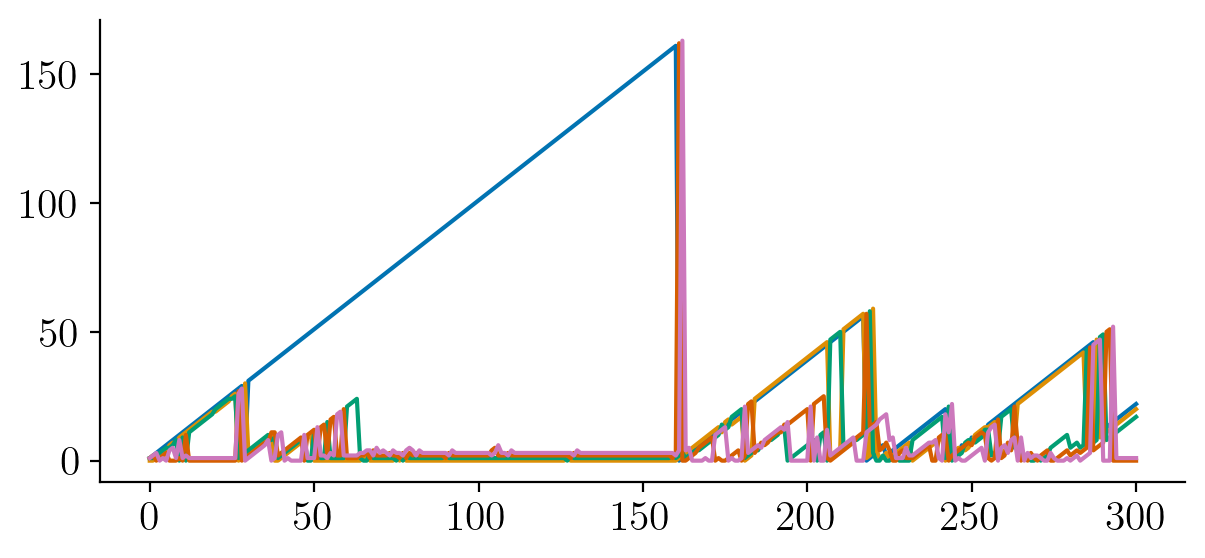

In [51]:
plt.plot(hist_rlpr["runlength"])

In [52]:
df_res_rlpr = pd.DataFrame({
    "forecast": np.asarray(hist_rlpr["yhat"]).squeeze(),
    "actual": y,
    "error": hist_rlpr["err"].squeeze(),
    "runlength": hist_rlpr["runlength"][:, 0].squeeze() / 12,
    "posterior": hist_rlpr["posterior"][:, 0].squeeze(),
    "date": df_norm.index[max(shifts):],
})
df_res_rlpr = df_res_rlpr.set_index("date")
posterior = df_res_rlpr["posterior"]

(0.0, 1.0)

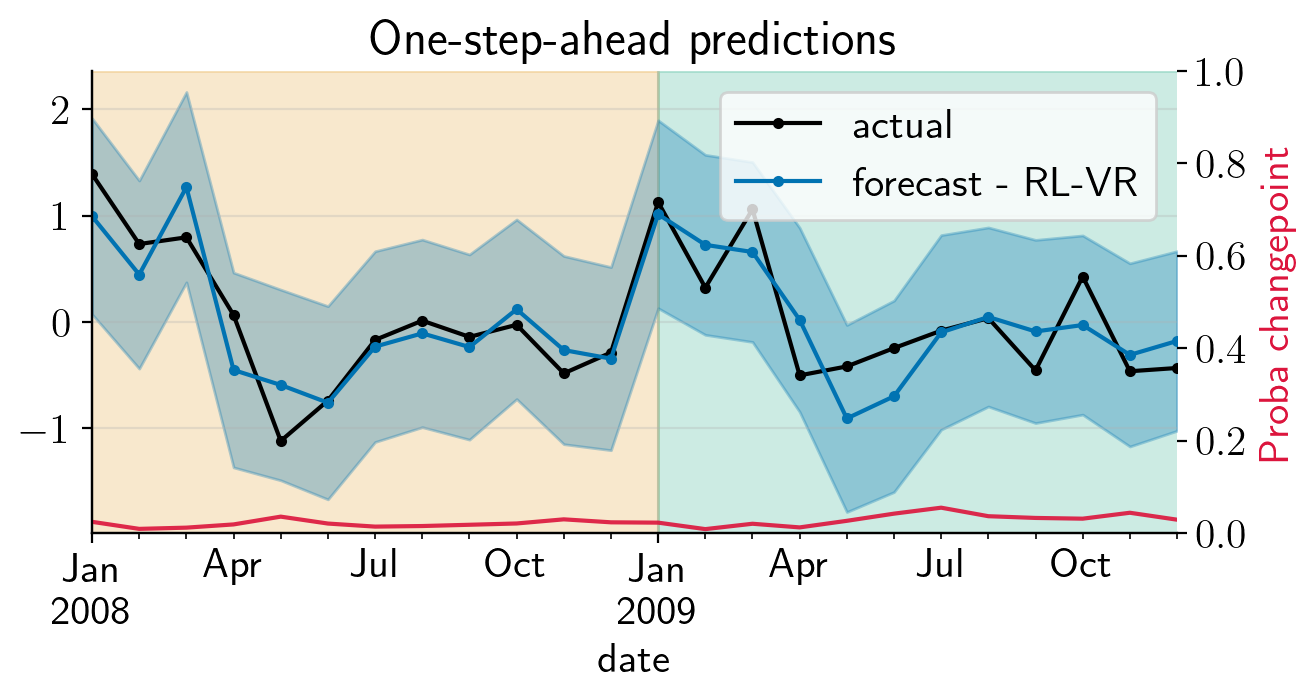

In [53]:
tslice = slice("2008", "2009")

window = df_res_rlpr.loc[tslice]
std = pd.Series(np.sqrt(np.asarray(hist_rlpr["cov"]).squeeze()), index=df_res_known_cp.index)

fig, ax = plt.subplots()
ax2 = ax.twinx()
window[["actual", "forecast"]].plot(ax=ax, marker="o", markersize=3, color=["black", "C0"])
ax.fill_between(
    window.index,
    (window["forecast"] - 2* std.loc[window.index]).values,
    (window["forecast"] + 2 * std.loc[window.index]).values,
    alpha=0.3,
    color="C0",
    # label="forecast +/- 2 std",
)
ax.legend()
plt.title("One-step-ahead predictions")
ax.grid(alpha=0.3)
ax.legend(["actual", "forecast - RL-VR"])

draw_spans_known(ax, alpha=0.2)

(1-posterior)[tslice].plot(ax=ax2, c="crimson", alpha=0.9)
ax2.set_ylabel("Proba changepoint", color="crimson")
ax2.set_ylim(0, 1)

# plt.savefig("../figures/ohe-forecast-rloupr-1.png", dpi=300, bbox_inches="tight")

(0.0, 1.0)

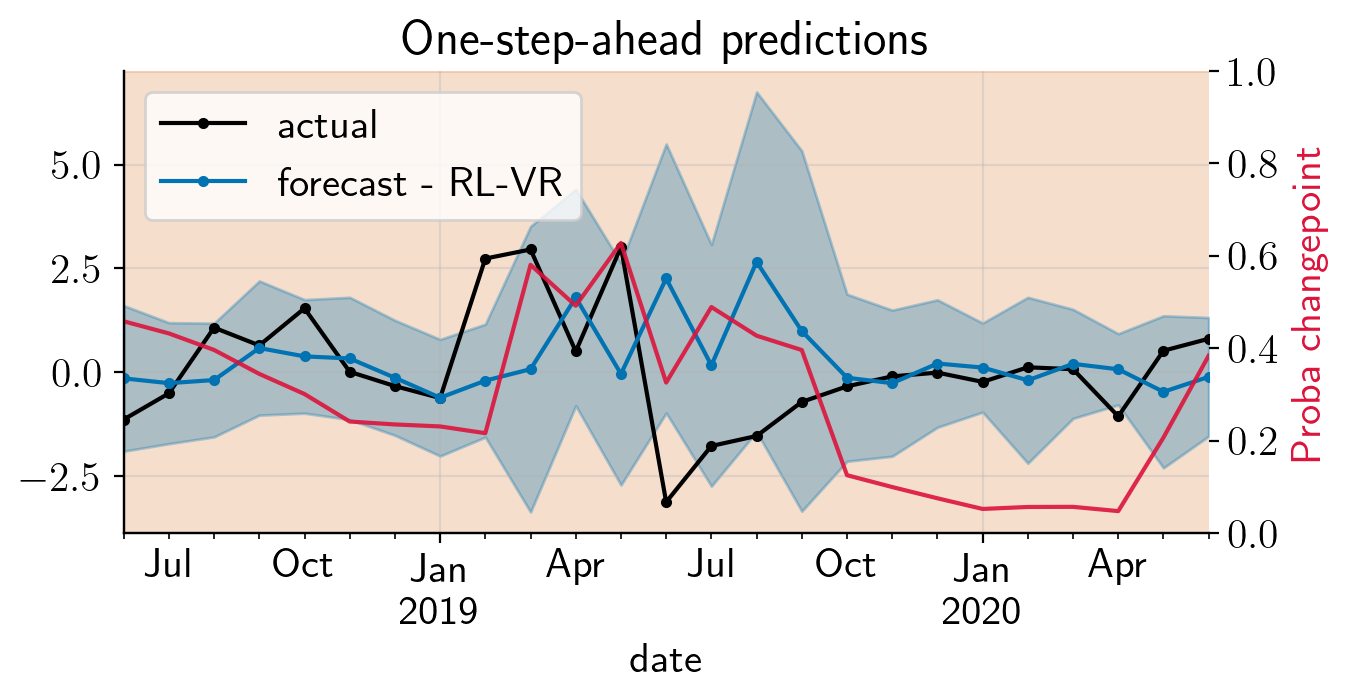

In [54]:
tslice = slice("2018-06", "2020-06")

window = df_res_rlpr.loc[tslice]
std = pd.Series(np.sqrt(np.asarray(hist_rlpr["cov"]).squeeze()), index=df_res_known_cp.index)

fig, ax = plt.subplots()
ax2 = ax.twinx()
window[["actual", "forecast"]].plot(ax=ax, marker="o", markersize=3, color=["black", "C0"])
ax.fill_between(
    window.index,
    (window["forecast"] - 2 * std.loc[window.index]).values,
    (window["forecast"] + 2 * std.loc[window.index]).values,
    alpha=0.3,
    color="C0",
    # label="forecast +/- 2 std",
)
ax.legend()
plt.title("One-step-ahead predictions")
ax.grid(alpha=0.3)
ax.legend(["actual", "forecast - RL-VR"])

draw_spans_known(ax, alpha=0.2)

(1-posterior)[tslice].plot(ax=ax2, c="crimson", alpha=0.9)
ax2.set_ylabel("Proba changepoint", color="crimson")
ax2.set_ylim(0, 1)

# plt.savefig("../figures/ohe-forecast-rloupr-2.png", dpi=300, bbox_inches="tight")

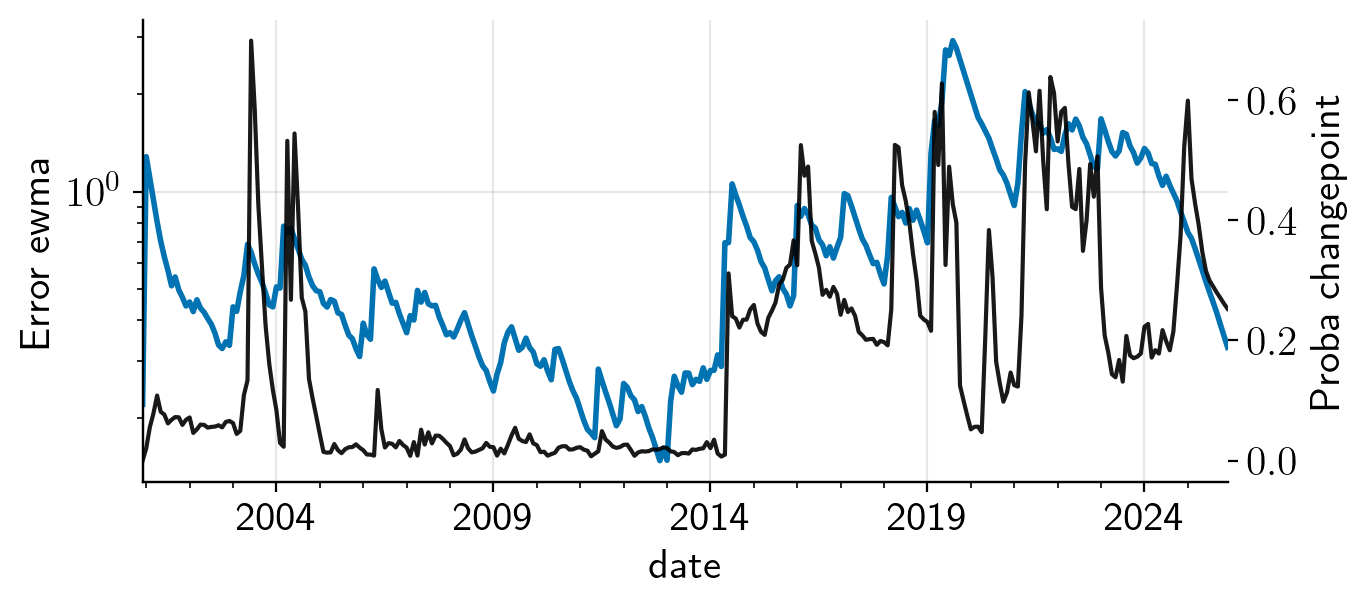

In [55]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
np.sqrt(np.power(df_res_rlpr["error"], 2).ewm(span=12).mean()).plot(ax=ax, label="rlpr", linewidth=2)
(1-posterior).plot(ax=ax2, c="black", alpha=0.9)
ax2.set_ylabel("Proba changepoint")
ax.set_ylabel("Error ewma")
ax.set_yscale("log")
ax.grid(alpha=0.3)

Text(0, 0.5, 'Median absolute error')

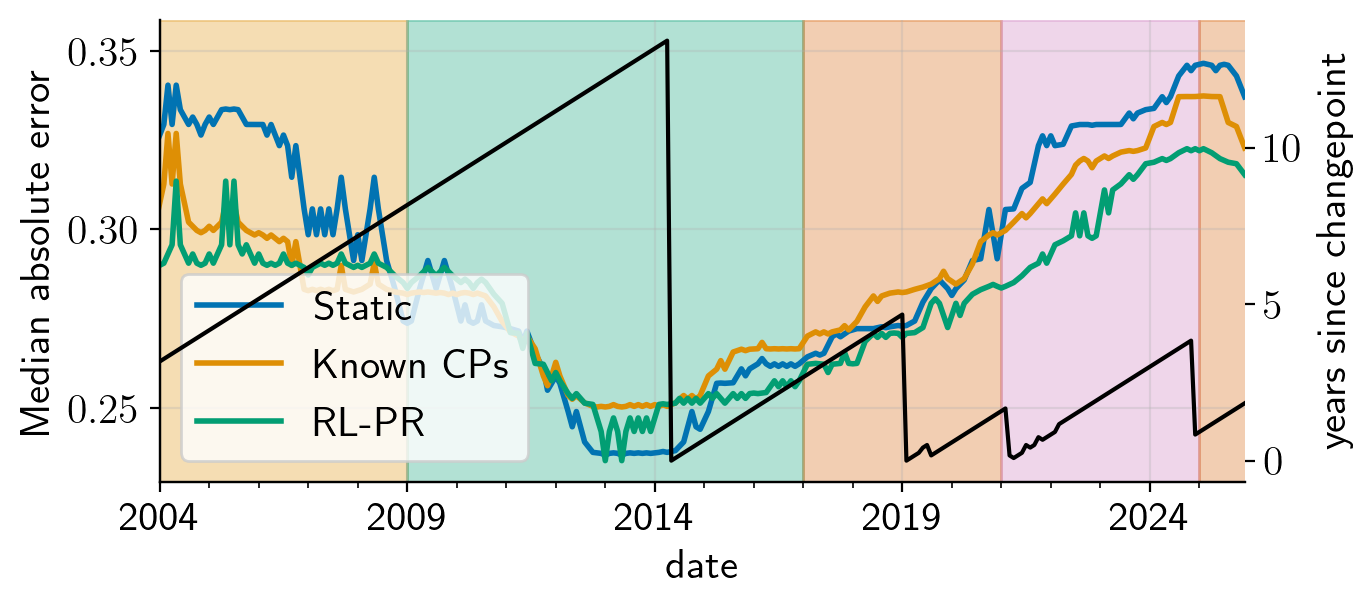

In [56]:
dfs_errors = pd.concat([
    df_res_cst["error"].rename("Static"),
    df_res_known_cp["error"].rename("Known CPs"),
    df_res_rlpr["error"].rename("RL-PR"),
], axis=1)

fig, ax = plt.subplots()
ax2 = ax.twinx()

np.abs(dfs_errors).expanding(12 * 2).median().plot(ax=ax, linewidth=2)

ax.grid(alpha=0.3)
ax.legend(loc="lower left")

draw_spans_known(ax, alpha=0.3)

df_res_rlpr["runlength"].plot(ax=ax2, c="black")

ax.set_xlim("2004", "2025-12")
ax2.set_ylabel("years since changepoint")
ax.set_ylabel("Median absolute error")

# plt.savefig("../figures/encounters-err-cst+kcp+rloupr.png", dpi=300, bbox_inches="tight")

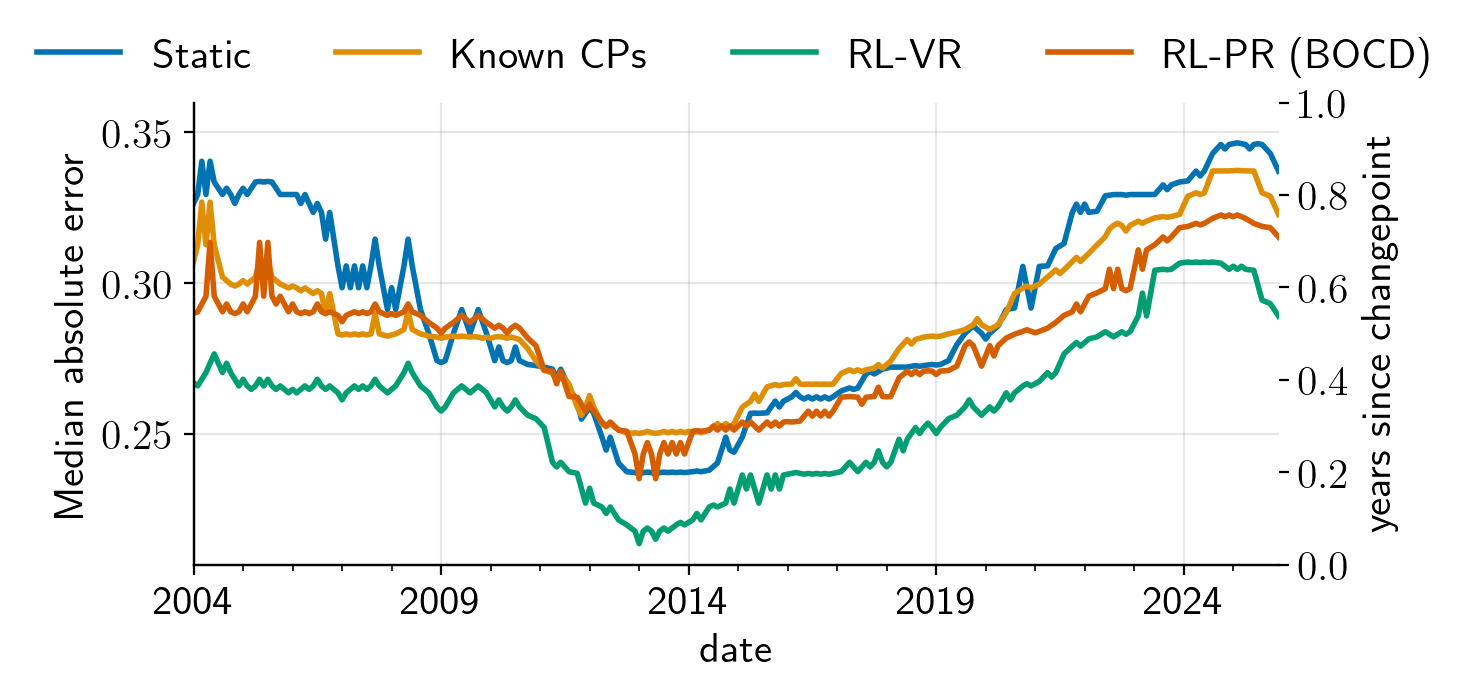

In [57]:
dfs_errors = pd.concat([
    df_res_cst["error"].rename("Static"),
    df_res_known_cp["error"].rename("Known CPs"),
    df_res_rlvr["error"].rename("RL-VR"),
    df_res_rlpr["error"].rename("RL-PR (BOCD)"),
], axis=1)

fig, ax = plt.subplots()
ax2 = ax.twinx()

np.abs(dfs_errors).expanding(12 * 2).median().plot(ax=ax, linewidth=2)

ax.grid(alpha=0.3)
ax.legend(ncol=4, loc="center", bbox_to_anchor=(1/2, 2.2 * 1/2), frameon=False)

# draw_spans_known(ax, alpha=0.3)




ax.set_xlim("2004", "2025-12")
ax2.set_ylabel("years since changepoint")
ax.set_ylabel("Median absolute error")

plt.savefig("../figures/encounters-err-cst+kcp+rlvr+rlpr.png", dpi=300, bbox_inches="tight")

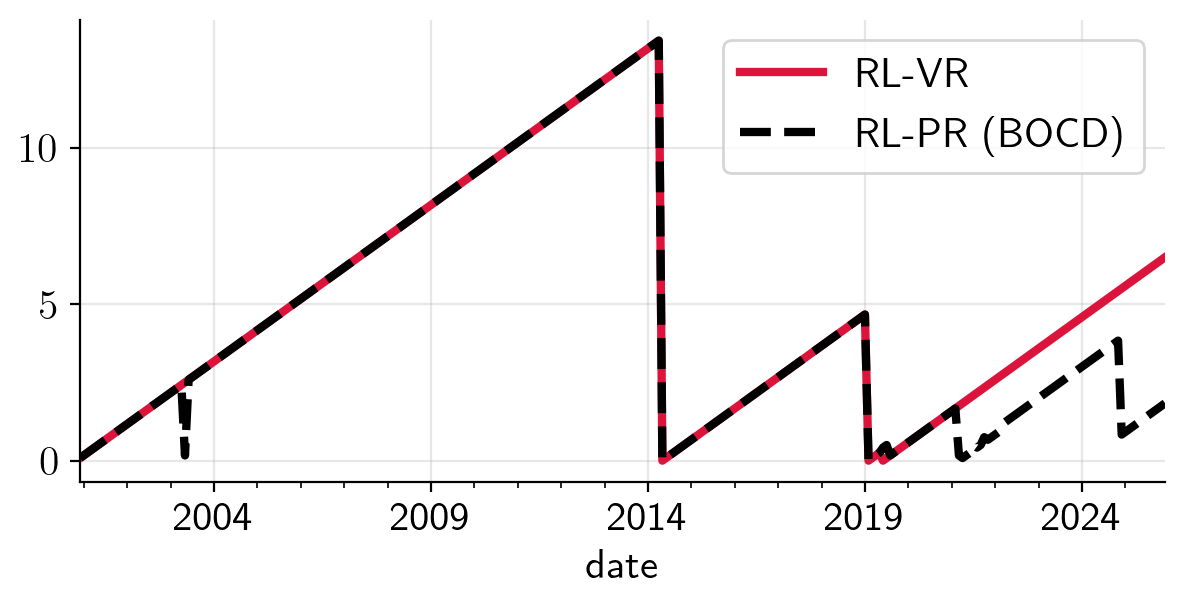

In [58]:
fig, ax = plt.subplots()
df_res_rlvr["runlength"].plot(ax=ax, c="crimson", linewidth=3, label="RL-VR")
df_res_rlpr["runlength"].plot(ax=ax, c="black", linestyle="--", linewidth=3, label="RL-PR (BOCD)")
plt.legend()
plt.grid(alpha=0.3)

## Baseline comparison

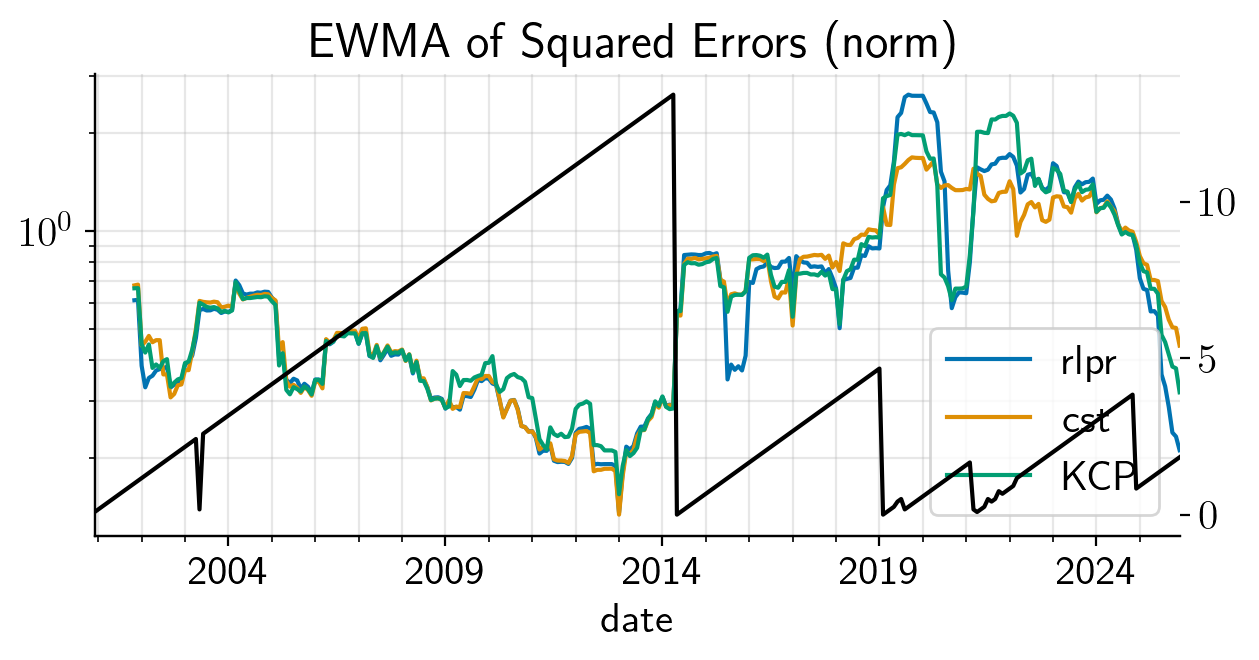

In [59]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
span = 12
np.sqrt(np.power(df_res_rlpr["error"], 2).rolling(span).mean()).plot(ax=ax, label="rlpr")
np.sqrt(np.power(df_res_cst["error"], 2).rolling(span).mean()).plot(ax=ax, label="cst")
np.sqrt(np.power(df_res_known_cp["error"], 2).rolling(span).mean()).plot(ax=ax, label="KCP")
ax.legend()
plt.title("EWMA of Squared Errors (norm)")

df_res_rlpr["runlength"].plot(ax=ax2, c="black")
ax.set_yscale("log")
ax.grid(alpha=0.3, which="both")

(576.0, 671.0)

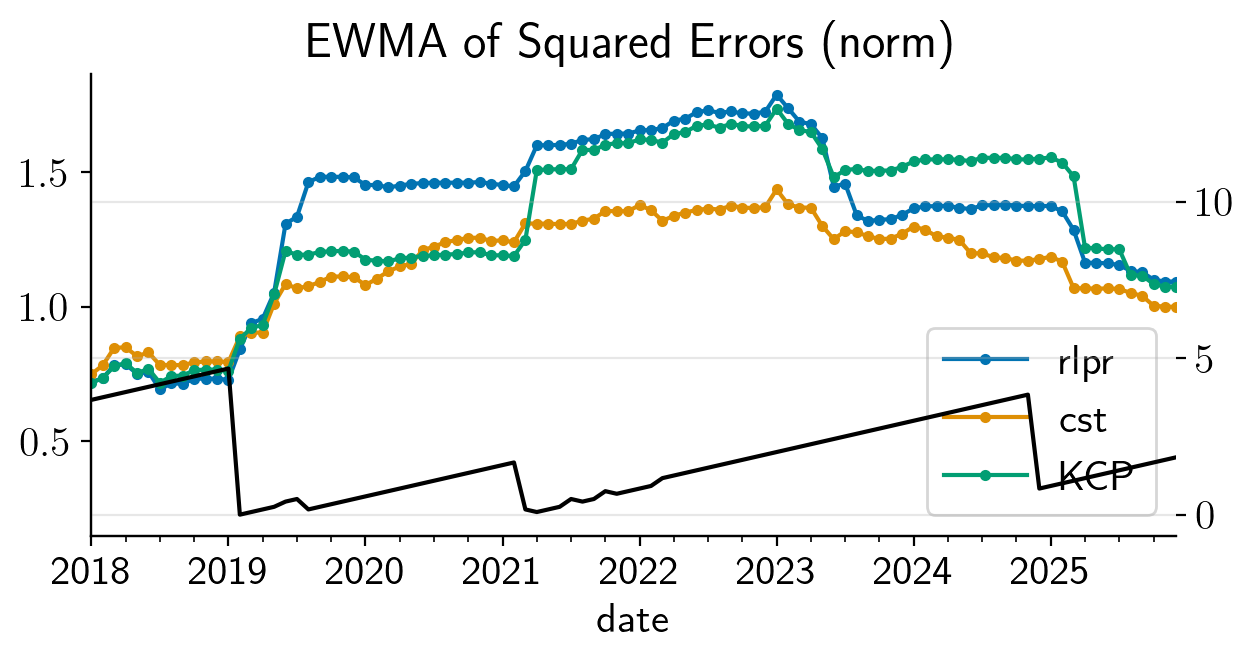

In [60]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
span = 48
np.sqrt(np.power(df_res_rlpr["error"], 2).rolling(span).mean()).plot(ax=ax, label="rlpr", marker="o", markersize=3)
np.sqrt(np.power(df_res_cst["error"], 2).rolling(span).mean()).plot(ax=ax, label="cst", marker="o", markersize=3)
np.sqrt(np.power(df_res_known_cp["error"], 2).rolling(span).mean()).plot(ax=ax, label="KCP", marker="o", markersize=3)

ax.legend()
plt.title("EWMA of Squared Errors (norm)")

df_res_rlpr["runlength"].plot(ax=ax2, c="black")
ax2.grid(alpha=0.3, which="both")
ax.set_xlim("2018", "2025-12")

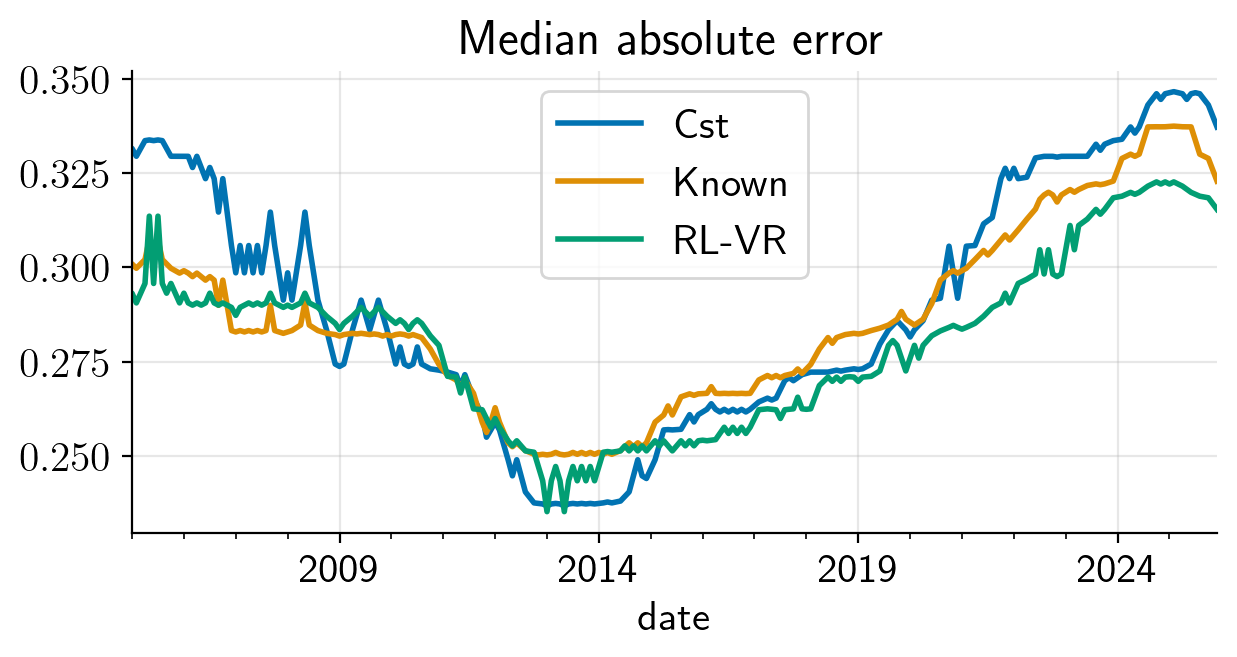

In [61]:
dfs_errors = pd.concat([
    df_res_cst["error"].rename("Cst"),
    df_res_known_cp["error"].rename("Known"),
    df_res_rlpr["error"].rename("RL-VR"),
], axis=1)

fig, ax = plt.subplots()

plt.title("Median absolute error")
np.abs(dfs_errors).expanding(48).median().plot(ax=ax, linewidth=2)
ax.set_xlim("2005", "2025-12")
plt.grid(alpha=0.3)

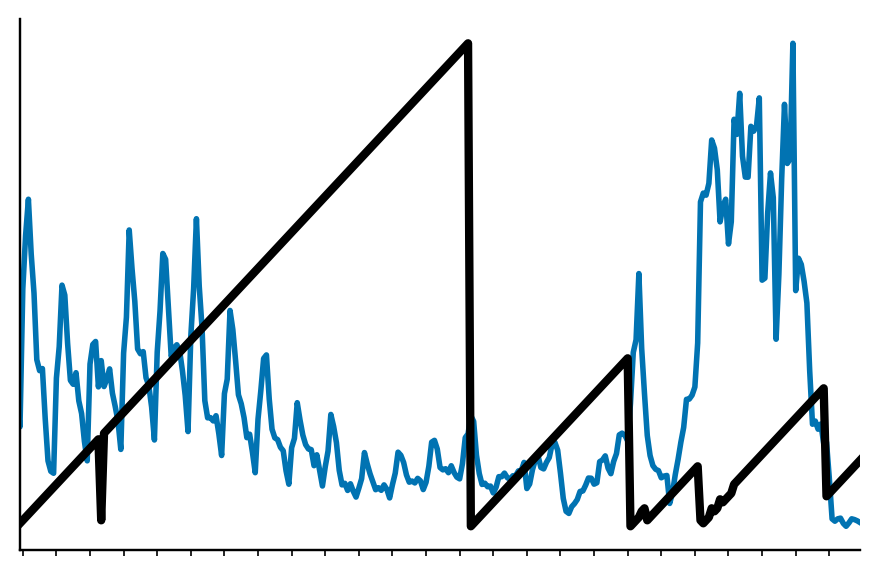

In [62]:
dpi = 100
fig, ax = plt.subplots(figsize=(542/dpi, 345/dpi), dpi=dpi)

ax2 = ax.twinx()
df["encounters"].plot(ax=ax, linewidth=2)
df_res_rlpr["runlength"].plot(ax=ax2, c="black", linewidth=3)
ax.set_xlabel("")
ax.set_yticks([])
ax2.set_yticks([])
ax.set_xticks([])
plt.savefig("./small-ts-changes.png", bbox_inches="tight")